# AI & ML Internship — Task 11
## SVM — Breast Cancer Classification

### Objective:
- Load Breast Cancer dataset
- Scale features
- Train SVM with Linear and RBF kernels
- Tune hyperparameters using GridSearchCV
- Evaluate using confusion matrix, classification report
- Plot ROC curve and compute AUC
- Save trained pipeline model


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn datasets & tools
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import joblib


In [3]:
# Load dataset from sklearn
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Dataset loaded successfully
Feature matrix shape: (569, 30)
Target shape: (569,)


In [4]:
# Check class distribution
unique, counts = np.unique(y, return_counts=True)

print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")


Class distribution:
Class 0: 212
Class 1: 357


In [5]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)


Training size: (455, 30)
Testing size : (114, 30)


In [6]:
# Build pipeline: scaling + SVM
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True))
])

# Train
linear_pipeline.fit(X_train, y_train)

# Predict
y_pred_linear = linear_pipeline.predict(X_test)

print("Linear SVM Accuracy:",
      accuracy_score(y_test, y_pred_linear))

print("\nClassification Report (Linear SVM):")
print(classification_report(y_test, y_pred_linear))


Linear SVM Accuracy: 0.9736842105263158

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [7]:
rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

rbf_pipeline.fit(X_train, y_train)

y_pred_rbf = rbf_pipeline.predict(X_test)

print("RBF SVM Accuracy:",
      accuracy_score(y_test, y_pred_rbf))


RBF SVM Accuracy: 0.9824561403508771


In [8]:
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.001]
}

grid_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

grid = GridSearchCV(
    grid_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'svm__C': 10, 'svm__gamma': 0.01}
Best CV Score: 0.9802197802197803


In [9]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned SVM Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)


Tuned SVM Accuracy: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[41  1]
 [ 1 71]]


AUC Score: 0.9976851851851851


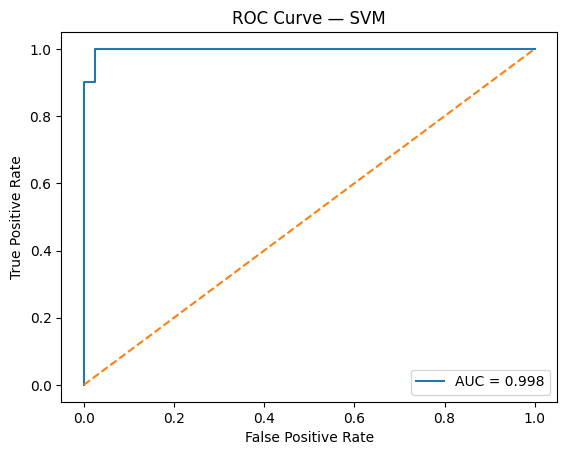

In [10]:
# Probability scores
y_prob = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM")
plt.legend()

plt.savefig("svm_roc_curve.png", bbox_inches="tight")
plt.show()


In [11]:
joblib.dump(best_model, "svm_breast_cancer_pipeline.pkl")

print("Model saved as svm_breast_cancer_pipeline.pkl")


Model saved as svm_breast_cancer_pipeline.pkl
